In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pysam
import pickle
import copy
import warnings
warnings.filterwarnings('ignore')

In [2]:
from alphagenome.data import genome
from alphagenome.models import dna_client

In [ ]:
df = pd.read_csv('./data/GATA1_oligo_synthesis_info.csv')

In [4]:
df = df[['WGATAR_id', 'type', 'oligo_230nt_chr','oligo_230nt_start', 'oligo_230nt_end','oligo_230nt_strand', 'oligo_seq_230nt']]

In [5]:
from pyliftover import LiftOver
lo = LiftOver('hg19', 'hg38')

In [6]:
hg38_s = []
hg38_e = []
for i,r in df.iterrows():
    ch = r['oligo_230nt_chr']
    s = r['oligo_230nt_start']
    e = r['oligo_230nt_end']
    
    hg38_s.append(lo.convert_coordinate(ch, s)[0][1])
    hg38_e.append(lo.convert_coordinate(ch, e)[0][1])

In [7]:
df['start_38'] = hg38_s
df['end_38'] = hg38_e
df = df.rename(columns={'oligo_230nt_chr':'chr', 'oligo_230nt_start':'start', 'oligo_230nt_end':'end', 'oligo_230nt_strand':'strand','oligo_seq_230nt':'seq'})

In [ ]:
tad = pd.read_csv('./data/TAD.csv', index_col=0)

tad = tad.drop_duplicates()

In [9]:
df = df.merge(tad, on='WGATAR_id')

In [10]:
df[['chrom', 'start_end']] = df['Hudep2_TAD_position'].str.split(':', expand=True)
df[['start_tad19', 'end_tad19']] = df['start_end'].str.split('-', expand=True)
df = df.drop(columns=['start_end', 'Hudep2_TAD_position'])  # Drop the intermediate column if you like

In [11]:
df['start_tad19'] = df['start_tad19'].astype(int)
df['end_tad19'] = df['end_tad19'].astype(int)

# df['width'] = -df['start_tad'] + df['end_tad']

In [12]:
hg38_s_t = []
hg38_e_t = []
for i,r in df.iterrows():
    ch = r['chr']
    s = r['start_tad19']
    e = r['end_tad19']
    
    hg38_s_t.append(lo.convert_coordinate(ch, s)[0][1])
    hg38_e_t.append(lo.convert_coordinate(ch, e)[0][1])

In [13]:
df['tad_start38'] = hg38_s_t
df['tad_end38'] = hg38_e_t

In [14]:
df = df[['WGATAR_id', 'type', 'chr', 'start', 'end', 'strand', 'seq', 'start_tad19', 'end_tad19']]

In [15]:
df.head()

,WGATAR_id,type,chr,start,end,strand,seq,start_tad19,end_tad19
0,WGATAR_18,modified,chr1,35646241,35646471,-,GCATTGTAACTGAAGATAACATGGAACACATCAGTGGTGTGGGGGA...,35630000,35890000
1,WGATAR_18,original,chr1,35646241,35646471,-,GCATTGTAACTGAAGATAACATGGAACACATCAGTGGTGTGGGGGA...,35630000,35890000
2,WGATAR_19,original,chr1,35646416,35646646,-,TACAGTGCAGCACCTAACACTTGTATGGTAAAGCTAGCTTACATCA...,35630000,35890000
3,WGATAR_19,modified,chr1,35646416,35646646,-,TACAGTGCAGCACCTAACACTTGTATGGTAAAGCTAGCTTACATCA...,35630000,35890000
4,WGATAR_20,original,chr1,35646340,35646570,-,ATTTGTCAGGCAGAATTCAGTGCTGTTGCAGTTCTCAGATAAAAAG...,35630000,35890000


In [16]:
df['dis_s'] = df['start'] + (df['end'] - df['start'])/2 - df['start_tad19']
df['dis_s'] = df['dis_s'].astype(int)

df['dis_e'] = df['end_tad19'] - (df['start'] + (df['end'] - df['start'])/2)
df['dis_e'] = df['dis_e'].astype(int)

df_distance = df[['WGATAR_id', 'dis_s', 'dis_e']]

In [ ]:
seq_length = 1048576
gata_length = 230
l = (seq_length - gata_length)/2
fasta = pysam.FastaFile('./data/hg19.fa')

In [19]:
GATA_id = list(df['WGATAR_id'])
seq_dict = {}
for i in GATA_id: 
    chrom = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'chr'])[0]
    s = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'start'])[0]
    e = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'end'])[0]

    start_seq = fasta.fetch(chrom, s-l, s)
    start_seq = start_seq.upper()
    end_seq = fasta.fetch(chrom, e, e+l)
    end_seq = end_seq.upper()
    
    so = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'original'), 'seq'])[0]
    so = so.upper()
    so = start_seq + so + end_seq
    sm = list(df.loc[(df['WGATAR_id'] == i) & (df['type'] == 'modified'), 'seq'])[0]
    sm = sm.upper()
    sm = start_seq + sm + end_seq

    seq_dict[i] = {'o':so, 'm':sm, 'start':s-l, 'end':e+l, 'chr':chrom}

In [52]:
###########################################################

In [ ]:
dna_model = dna_client.create('your_api_key')

In [54]:
# output_metadata = dna_model.output_metadata(
#     dna_client.Organism.HOMO_SAPIENS
# ).concatenate()

# output_metadata.to_csv('model_metadata.csv')

In [55]:
output_type = dna_client.OutputType.RNA_SEQ
output_term = 'EFO:0002067'

In [56]:
gata_rna_o = pd.DataFrame({'A': range(1048576)})
gata_rna_m = pd.DataFrame({'A': range(1048576)})
key_list = list( seq_dict.keys())

to_process = set(key_list)
max_attempts = 20

for attempt in range(max_attempts):
    print(f"Attempt {attempt + 1} with {len(to_process)} keys remaining.")
    failed_keys = set()
    for k in tqdm(to_process):
        try:

            seq_record = seq_dict[k]
            o = seq_record['o']
            m = seq_record['m']
        
            output_o = dna_model.predict_sequence(
            sequence=o.center(1048576, 'N'),  # Pad to valid sequence length.
            requested_outputs=[output_type],
            ontology_terms=[output_term],  # K562.
            )
        
            output_m = dna_model.predict_sequence(
            sequence=m.center(1048576, 'N'),  # Pad to valid sequence length.
            requested_outputs=[output_type],
            ontology_terms=[output_term],  # K562.
            )
        
            output_o = output_o.rna_seq.filter_to_unstranded().values
            output_o = output_o.reshape(-1)
            output_m = output_m.rna_seq.filter_to_unstranded().values
            output_m = output_m.reshape(-1)
            
            gata_rna_o[k] = output_o
            gata_rna_m[k] = output_m
        except Exception as e:
            if 'RESOURCE_EXHAUSTED' in str(e):
                print(f"Quota exceeded for key {k}, will retry...")
                failed_keys.add(k)
                time.sleep(30)  # Consider sleeping outside the loop for bulk wait
            else:
                raise
    # Only process failed keys in the next attempt
    to_process = failed_keys
    if not to_process:
        print("All keys processed successfully!")
        break
    else:
        print(f"Finished {max_attempts} attempts, {len(to_process)} keys failed: {to_process}")
        

Attempt 1 with 1200 keys remaining.


100%|██████████| 1200/1200 [51:35<00:00,  2.58s/it] 

All keys processed successfully!


In [ ]:
gata_rna_o.to_pickle('./data/GATA_RNA_prediction_original_all.pkl')
gata_rna_m.to_pickle('./data/GATA_RNA_prediction_modified_all.pkl')

In [61]:
#################################################################

In [ ]:
gata_rna_o = pd.read_pickle('./data/GATA_RNA_prediction_original_all.pkl')
gata_rna_m = pd.read_pickle('./data/GATA_RNA_prediction_modified_all.pkl')

In [19]:
gata_rna_o.head()

,A,WGATAR_252,WGATAR_1241,WGATAR_1829,WGATAR_1162,WGATAR_1466,WGATAR_595,WGATAR_2431,WGATAR_1078,WGATAR_2448,...,WGATAR_1180,WGATAR_2287,WGATAR_53,WGATAR_1156,WGATAR_253,WGATAR_934,WGATAR_35,WGATAR_267,WGATAR_2069,WGATAR_718
0,0,0.000023,0.000721,0.000050,0.000690,0.004150,0.000125,0.000244,0.018799,0.000374,...,0.000062,0.000125,0.006073,0.000072,0.000026,0.000404,0.000148,0.000012,0.000014,0.000009
1,1,0.000033,0.001053,0.000076,0.000973,0.005341,0.000175,0.000355,0.024170,0.000641,...,0.000094,0.000169,0.008057,0.000094,0.000036,0.000568,0.000198,0.000018,0.000020,0.000013
2,2,0.000042,0.001297,0.000086,0.001244,0.006073,0.000207,0.000437,0.028320,0.000671,...,0.000115,0.000207,0.009216,0.000115,0.000046,0.000641,0.000256,0.000026,0.000026,0.000017
3,3,0.000042,0.001297,0.000083,0.001297,0.006073,0.000198,0.000420,0.028320,0.000671,...,0.000110,0.000216,0.008789,0.000115,0.000046,0.000641,0.000277,0.000026,0.000026,0.000018
4,4,0.000036,0.001144,0.000072,0.001053,0.005554,0.000182,0.000374,0.025146,0.000568,...,0.000094,0.000207,0.008423,0.000103,0.000042,0.000568,0.000244,0.000023,0.000023,0.000018


In [20]:
gata_rna_o = gata_rna_o.drop('A', axis=1)
gata_rna_m = gata_rna_m.drop('A', axis=1)

In [ ]:
exon = pd.read_csv('./data/gene_exon.bed', sep='\t', header=None)
exon = exon[[0,1,2,5]]
exon.columns = ['chr','start','end','strand']
exon['id'] = exon['chr'] + ':' + exon['start'].astype(str) + '-' + exon['end'].astype(str)

In [22]:
exon.head()

,chr,start,end,strand,id
0,chr1,12189,12227,+,chr1:12189-12227
1,chr1,12594,12721,+,chr1:12594-12721
2,chr1,13402,13639,+,chr1:13402-13639
3,chr1,69090,70008,+,chr1:69090-70008
4,chr1,138529,139696,-,chr1:138529-139696


In [ ]:
total_o = []
total_m = []
ids = []

for k, v in tqdm(seq_dict.items()):
    s = v['start']
    e = v['end']
    chrom = v['chr']

    exon_filter = exon[(exon['chr']==chrom)&(exon['start']>=s)&(exon['end']<=e)]

    for i,r in exon_filter.iterrows():
        start = r['start'] - s
        end = r['end'] - s
        exon_id = r['id']


        o_k = gata_rna_o.loc[start:end][k].mean()
        m_k = gata_rna_m.loc[start:end][k].mean()

        total_o.append(copy.deepcopy(o_k))
        total_m.append(copy.deepcopy(m_k))
        ids.append((k, exon_id))
        

In [ ]:
with open('./data/exon_prediction.pkl', 'wb') as f:
    pickle.dump((total_o, total_m, ids), f)

In [ ]:
with open('./data/exon_prediction.pkl', 'rb') as f:
    total_o, total_m, ids = pickle.load(f)

In [4]:
original = np.array(total_o)
modified = np.array(total_m)
label_array = np.array(ids)

data = pd.DataFrame({'original':original, 'modified': modified, 'id':label_array[:,0], 'coordinate':label_array[:,1]})

In [5]:
data['del'] = data['original'] - data['modified']

In [6]:
data = data.drop_duplicates()

In [7]:
data_max = data.loc[data.groupby('id')['del'].idxmax()]

In [8]:
data_max

,original,modified,id,coordinate,del
113693,164.632080,164.430023,WGATAR_1064,chr16:2012497-2012657,0.202057
115270,13.412852,13.338908,WGATAR_1065,chr16:70605575-70605716,0.073944
115590,6.449183,6.415525,WGATAR_1066,chr16:70292882-70293089,0.033659
116545,11.103661,11.049994,WGATAR_1067,chr16:70604997-70605102,0.053667
117194,6.507633,6.478652,WGATAR_1068,chr16:70594371-70594494,0.028982
...,...,...,...,...,...
109230,6.210979,6.179288,WGATAR_987,chr15:42851536-42851606,0.031691
110253,7.601689,7.577311,WGATAR_988,chr15:42853493-42853600,0.024378
110867,4.358963,4.341385,WGATAR_989,chr15:42510000-42510031,0.017578
112286,6.060751,6.010551,WGATAR_990,chr15:42850395-42850488,0.050200


In [ ]:
data_max.to_csv('./data/alphaGenome_1M_max.csv', index=None)

In [10]:
original = np.array(data_max['original'])
modified = np.array(data_max['modified'])
label_array = np.array(data_max['id'])
exon = np.array(data_max['coordinate'])
# Calculate distances from the diagonal
distances = np.abs(modified - original) / np.sqrt(2)

# Define a threshold, e.g., 3 standard deviations from the mean
threshold = np.mean(distances) + 10* np.std(distances)
outlier_indices = np.where(distances > threshold)[0]

# Outlier points
outlier_points = pd.DataFrame({"original": original[outlier_indices],
                               "modified": modified[outlier_indices],
                               "WGATA_id": label_array[outlier_indices],
                               "exon_id": exon[outlier_indices]})

In [ ]:
outlier_points.to_csv("./data/outliers_max.csv", index=None)

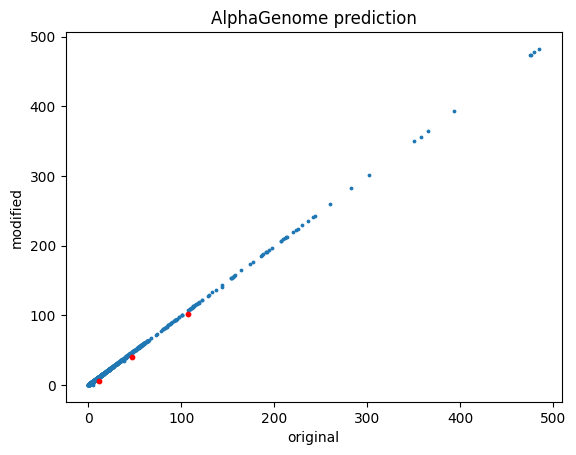

In [12]:
plt.scatter(original, modified, s=3)
plt.scatter(original[outlier_indices], modified[outlier_indices], color='red', s=10)  # Highlight outliers
# plt.plot([0, 500], [0, 500], 'k--')
# plt.xlim([0,500])
# plt.ylim([0,500])
plt.xlabel('original')
plt.ylabel('modified')
plt.title('AlphaGenome prediction')
plt.show()

In [13]:
#############################

In [ ]:
df = pd.read_csv('./data/S1_WGATAR_uq_DESeq2_with_TF.csv')

In [15]:
df = df[['WGATAR_id', 'effect2']]

In [16]:
d = dict(zip(df['WGATAR_id'], df['effect2']))

In [17]:
data_max['effect'] = data_max['id'].map(d)

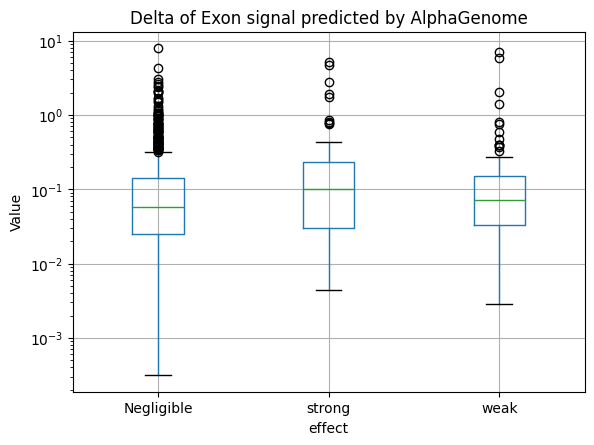

In [18]:
data_max.boxplot(column='del', by='effect', grid=True, showfliers=True)
plt.title('Delta of Exon signal predicted by AlphaGenome')
plt.suptitle('')  # remove automatic title
plt.xlabel('effect')
plt.ylabel('Value')
plt.yscale('log')  
plt.show()

In [ ]:
data.to_csv('./data/alphaGenome_1M.csv', index=None)

In [20]:
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [21]:
pairs, pvals = [], []
cats = data_max["effect"].dropna().unique()
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        a = data_max.loc[data_max["effect"]==cats[i], "del"]
        b = data_max.loc[data_max["effect"]==cats[j], "del"]
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        pairs.append((cats[i], cats[j]))
        pvals.append(p)

rej, p_corr, _, _ = multipletests(pvals, method="fdr_bh")
for (a,b), p_raw, p_adj, r in zip(pairs, pvals, p_corr, rej):
    print(f"{a} vs {b}: p_raw={p_raw:.3g}, p_adj={p_adj:.3g}, significant={bool(r)}")

Negligible vs weak: p_raw=0.0487, p_adj=0.131, significant=False
Negligible vs strong: p_raw=0.0871, p_adj=0.131, significant=False
weak vs strong: p_raw=0.754, p_adj=0.754, significant=False
